In [1]:
import os
import time
import pandas as pd
import akshare as ak
import datetime
import psycopg2
import warnings
from datetime import timedelta, datetime
warnings.filterwarnings("ignore")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('expand_frame_repr', False)
pd.set_option('display.unicode.ambiguous_as_wide', True)
pd.set_option('display.unicode.east_asian_width', True)

# Connect to Database

In [2]:
conn = psycopg2.connect(host="localhost", database="yuzhuoran", user="postgres", password="YZRyzr010306!")

In [3]:
def SQLSearch(s:str):
    cur = conn.cursor()
    conn.commit()
    conn.rollback()
    conn.autocommit = True
    cur.execute(s)
    col_names = [desc [0] for desc in cur.description]
    results = cur.fetchall()
    cur.close()
    return col_names,results

In [4]:
sql = "SELECT * from \"Trading\".Fact_Stock_Daily\
                where Date_ID>=20230101 and Stock_ID=600035;"
col,res = SQLSearch(sql)

In [5]:
df = pd.DataFrame(res,columns=col)
df.tail()

,fsd_id,stock_id,date_id,open,high,low,volume,turnover,amplitude,percent_of_incre_decre,amount_of_incre_decre,turnover_rate,close
217,20231127600035,600035,20231127,3.99,4.00,3.93,134076,52868809.00,1.76,-0.75,-0.03,0.83,3.95
218,20231128600035,600035,20231128,3.94,3.96,3.92,80708,31847509.00,1.01,0.25,0.01,0.50,3.96
219,20231129600035,600035,20231129,3.95,3.98,3.93,71940,28419122.00,1.26,-0.76,-0.03,0.45,3.93
220,20231130600035,600035,20231130,3.94,3.97,3.92,85978,33974412.00,1.27,0.76,0.03,0.53,3.96
221,20231201600035,600035,20231201,3.96,4.02,3.94,130370,52033625.00,2.02,1.01,0.04,0.81,4.00


# Daily Kindle Visualization

In [6]:
import mplfinance as mpf
import matplotlib.pyplot as plt
from pylab import mpl

In [8]:
oclhv = df[['date_id','open','high','low','volume']]
col = ['date','open','high','low','volume']
oclhv.columns = col
oclhv['open'] = pd.to_numeric(oclhv['open'],errors='coerce')
oclhv['close'] = oclhv['open'].shift(-1)
oclhv['high'] = pd.to_numeric(oclhv['high'],errors='coerce')
oclhv['low'] = pd.to_numeric(oclhv['low'],errors='coerce')
oclhv['volume'] = pd.to_numeric(oclhv['volume'],errors='coerce')
oclhv['date'] = pd.to_datetime(oclhv['date'],format='%Y%m%d')
oclhv = oclhv.set_index('date',drop=True)
oclhv['close'][-1] = oclhv['open'][-1]
oclhv.tail()

,open,high,low,volume,close
date,,,,,
2023-11-27,3.99,4.00,3.93,134076,3.94
2023-11-28,3.94,3.96,3.92,80708,3.95
2023-11-29,3.95,3.98,3.93,71940,3.94
2023-11-30,3.94,3.97,3.92,85978,3.96
2023-12-01,3.96,4.02,3.94,130370,3.96


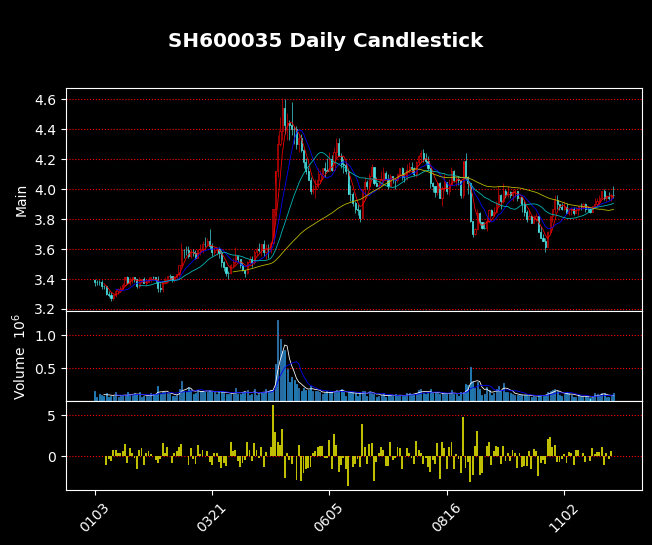

In [9]:
def style_model_dark():
    mc = mpf.make_marketcolors(up='black',down='#54fcfc', #up='black',down='#54fcfc',
                               edge= {'up':'r','down':'#54fcfc'},
                               wick={'up':'r','down':'#54fcfc'},
                               volume={'up':'r','down':'#54fcfc'},
                               ohlc='black')
    mavc = ['white', 'blue', 'yellow', '#1f77b4',
                 '#ff7f0e', '#2ca02c', '#e377c2']
    grid_kwargs = dict(
                    gridcolor     = 'red',
                    gridstyle     = ':',
                    gridaxis =     'horizontal',
                    rc={
                        #'font.family': 'SimHei',
                        'patch.linewidth' : 1.5,
                        'lines.linewidth' : 1.5,
                        'figure.titlesize' : 'x-large',
                        'figure.titleweight' : 'semibold'
                    },
                       )
    s = mpf.make_mpf_style(base_mpl_style='dark_background',
                           marketcolors=mc,facecolor = 'black',y_on_right=False,mavcolors = mavc,**grid_kwargs )
    return s

s = style_model_dark()
kwargs = dict(
    type='candle',
    datetime_format='%m%d',
    title='\n SH600035 Daily Candlestick',
    ylabel='Main',
    style = s,
)
# Calculate Means
ma5 = oclhv.close.rolling(5).mean()
ma10 = oclhv.close.rolling(10).mean()
ma20 = oclhv.close.rolling(20).mean()
ma60 = oclhv.close.rolling(60).mean()

#Calculate FLB = rise/mean of 5 days volume
rise = oclhv.close.pct_change()
LB = oclhv.volume / oclhv.volume.rolling(5).mean()
FLB = (rise / LB * 100).round(2)

#Calculate MAs for volume
vol_ma5 = oclhv.volume.rolling(5).mean()
vol_ma10 = oclhv.volume.rolling(10).mean()

# Add Parameters
ap0 = [
    mpf.make_addplot(ma5, color = 'r'),
    mpf.make_addplot(ma10, color = 'b'),
    mpf.make_addplot(ma20, color = 'c'),
    mpf.make_addplot(ma60, color = 'y'),
    
    mpf.make_addplot(vol_ma5, color='w',panel=1),
    mpf.make_addplot(vol_ma10, color='b',panel=1),
    
    mpf.make_addplot(FLB, type='bar', color='y', panel=2)
]
# Paint Main Klines
mpf.plot(
    oclhv,
    **kwargs,
    volume = True,scale_width_adjustment = dict(volume=0.5, candle=1.15,lines=0.45),
    addplot = ap0,
)
mpf.show()

# Minute Candlestick Visualization

In [51]:
sql2 = "SELECT * FROM \"Trading\".Fact_Stock_Minute fsm JOIN \"Trading\".Dim_Minute dm \
                ON fsm.Minute_ID = dm.Minute_ID \
                WHERE DATE_TRUNC('day',CAST(dm.date AS timestamp))='2023-11-21'\
                AND fsm.Stock_ID = 600035;"
col2,res2 = SQLSearch(sql2)
df2 = pd.DataFrame(res2,columns=col2)
df2

,fsm_id,stock_id,minute_id,open,high,low,volume,stock_name,turnover,close,minute_id,hour,minute,date
0,600035202311210930,600035,202311210930,0.00,3.89,3.89,2424,楚天高速,942936.00,3.89,202311210930,9,30,2023-11-21 09:30:00
1,600035202311210931,600035,202311210931,0.00,3.90,3.88,1540,楚天高速,598811.00,3.89,202311210931,9,31,2023-11-21 09:31:00
2,600035202311210932,600035,202311210932,0.00,3.90,3.89,217,楚天高速,84519.00,3.90,202311210932,9,32,2023-11-21 09:32:00
3,600035202311210933,600035,202311210933,0.00,3.90,3.89,760,楚天高速,295663.00,3.90,202311210933,9,33,2023-11-21 09:33:00
4,600035202311210934,600035,202311210934,0.00,3.90,3.89,337,楚天高速,131289.00,3.90,202311210934,9,34,2023-11-21 09:34:00
5,600035202311210935,600035,202311210935,0.00,3.90,3.89,293,楚天高速,114227.00,3.90,202311210935,9,35,2023-11-21 09:35:00
6,600035202311210936,600035,202311210936,0.00,3.90,3.89,221,楚天高速,86171.00,3.90,202311210936,9,36,2023-11-21 09:36:00
7,600035202311210937,600035,202311210937,0.00,3.90,3.89,1165,楚天高速,453392.00,3.89,202311210937,9,37,2023-11-21 09:37:00
8,600035202311210938,600035,202311210938,0.00,3.90,3.89,465,楚天高速,181267.00,3.90,202311210938,9,38,2023-11-21 09:38:00
9,600035202311210939,600035,202311210939,0.00,3.90,3.89,144,楚天高速,56152.00,3.90,202311210939,9,39,2023-11-21 09:39:00


In [65]:
oclhv2 = df2[['date','open','close','high','low','volume']]
oclhv2['close'] = pd.to_numeric(oclhv2['close'],errors='coerce')
oclhv2['open'] = oclhv2['close'].shift(1)
oclhv2['high'] = pd.to_numeric(oclhv2['high'],errors='coerce')
oclhv2['low'] = pd.to_numeric(oclhv2['low'],errors='coerce')
oclhv2['volume'] = pd.to_numeric(oclhv2['volume'],errors='coerce')
oclhv2['date'] = pd.to_datetime(oclhv2['date'])
oclhv2 = oclhv2.set_index('date',drop=True)
oclhv2['open'][0] = oclhv2['low'][0]
oclhv2

,open,close,high,low,volume
date,,,,,
2023-11-21 09:30:00,3.89,3.89,3.89,3.89,2424
2023-11-21 09:31:00,3.89,3.89,3.90,3.88,1540
2023-11-21 09:32:00,3.89,3.90,3.90,3.89,217
2023-11-21 09:33:00,3.90,3.90,3.90,3.89,760
2023-11-21 09:34:00,3.90,3.90,3.90,3.89,337
2023-11-21 09:35:00,3.90,3.90,3.90,3.89,293
2023-11-21 09:36:00,3.90,3.90,3.90,3.89,221
2023-11-21 09:37:00,3.90,3.89,3.90,3.89,1165
2023-11-21 09:38:00,3.89,3.90,3.90,3.89,465


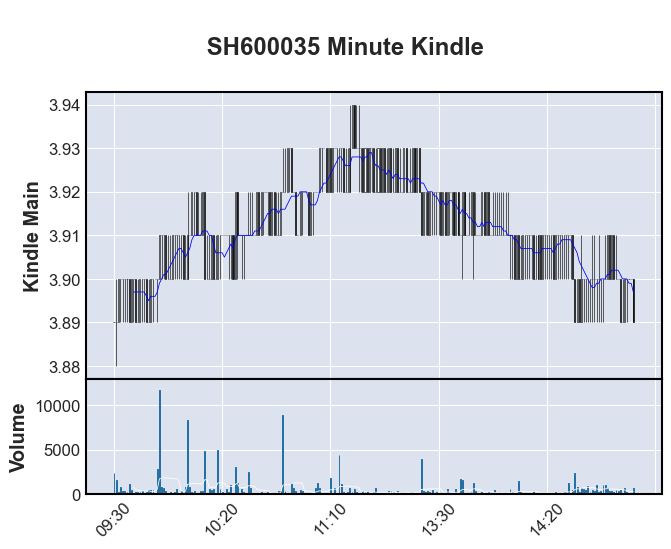

In [69]:
kwargs2 = dict(
    type='candle',
    #datetime_format='%Y-%m-%d %h-%m-%s',
    title='\n SH600035 Minute Kindle',
    ylabel='Kindle Main',
    #style = s,
)

ma10 = oclhv2.close.rolling(10).mean()

#Calculate MAs for volume
vol_ma10 = oclhv2.volume.rolling(10).mean()

# Add Parameters
ap20 = [
    mpf.make_addplot(ma10, color = 'b'),
    
    mpf.make_addplot(vol_ma10, color='w',panel=1),
]
# Paint Main Klines
mpf.plot(
    oclhv2,
    **kwargs2,
    volume = True,scale_width_adjustment = dict(volume=0.5, candle=1.15,lines=0.45),
    addplot = ap20,
)
mpf.show()